# Regresión Lineal Simple: Leads Reales (GAC)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#Cargamos el archivo csv con pandas (equivalente al paso de sns.load_dataset del notebook base)
df_leads = pd.read_csv('Leads_Reales_Limpia.csv')
df_leads.head(10)


,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion (%),Efectividad de Leads (%)
0,2024,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024,Febrero,543.0,108.0,33.0,0.0,1.0,389.0,1.0,12.0,3.1,72.0
2,2024,Marzo,178.0,37.0,13.0,0.0,0.0,128.0,1.0,7.0,5.5,72.0
3,2024,Abril,416.0,79.0,46.0,3.0,0.0,288.0,1.0,8.0,2.8,69.0
4,2024,Mayo,422.0,33.0,100.0,17.0,0.0,274.0,5.0,13.0,4.7,65.0
5,2024,Junio,967.0,140.0,173.0,31.0,3.0,620.0,17.0,6.0,1.0,64.0
6,2024,Julio,954.0,112.0,251.0,12.0,9.0,570.0,5.0,21.0,3.7,60.0
7,2024,Agosto,1409.0,504.0,324.0,17.0,18.0,546.0,22.0,17.0,3.1,39.0
8,2024,Septiembre,1315.0,431.0,314.0,14.0,26.0,530.0,42.0,17.0,3.2,40.0
9,2024,Octubre,1973.0,514.0,606.0,18.0,13.0,822.0,72.0,23.0,2.8,42.0


In [4]:
#Revisamos tipos de dato y nulos antes de limpiar
df_leads.info()
df_leads.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Año                       29 non-null     int64  
 1   Mes                       29 non-null     str    
 2   Total                     28 non-null     float64
 3   Ilocalizable              28 non-null     float64
 4   No Contesta               28 non-null     float64
 5   D. Incorrectos            28 non-null     float64
 6   Duplicados                28 non-null     float64
 7   Efectivos                 28 non-null     float64
 8   Abiertos                  28 non-null     float64
 9   Ventas                    28 non-null     float64
 10  Conversion (%)            28 non-null     float64
 11  Efectividad de Leads (%)  28 non-null     float64
dtypes: float64(10), int64(1), str(1)
memory usage: 2.8 KB


Año                         0
Mes                         0
Total                       1
Ilocalizable                1
No Contesta                 1
D. Incorrectos              1
Duplicados                  1
Efectivos                   1
Abiertos                    1
Ventas                      1
Conversion (%)              1
Efectividad de Leads (%)    1
dtype: int64

In [5]:
#Imputamos los nulos de "Año" propagando el año hacia adelante y forzamos tipo numérico (int)
df_leads['Año'] = df_leads['Año'].ffill()
df_leads['Año'] = pd.to_numeric(df_leads['Año'], errors='coerce').astype(int)
df_leads['Año'].unique()


array([2024, 2025, 2026])

In [6]:
#Diccionario de equivalencia mes-texto -> mes-numero
meses_num = {
    'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4,
    'Mayo': 5, 'Junio': 6, 'Julio': 7, 'Agosto': 8,
    'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12
}

#Reemplazamos los valores categóricos de "Mes" por su número correspondiente y convertimos a numérico (int)
df_leads['Mes'] = df_leads['Mes'].str.strip().map(meses_num)
df_leads['Mes'] = pd.to_numeric(df_leads['Mes'], errors='coerce').astype(int)
df_leads[['Año', 'Mes']].dtypes


Año    int64
Mes    int64
dtype: object

In [7]:
#Confirmamos que Año y Mes ya son numéricos
df_leads.dtypes


Año                           int64
Mes                           int64
Total                       float64
Ilocalizable                float64
No Contesta                 float64
D. Incorrectos              float64
Duplicados                  float64
Efectivos                   float64
Abiertos                    float64
Ventas                      float64
Conversion (%)              float64
Efectividad de Leads (%)    float64
dtype: object

In [8]:
#Filas con datos de Leads nulos (no se pueden usar en el análisis de correlación/regresión)
df_leads[df_leads['Total'].isnull()]


,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion (%),Efectividad de Leads (%)
0,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
#Creamos un dataframe sin nulos para el análisis de correlación y el modelo de regresión
df_leads_completo = df_leads.dropna().reset_index(drop=True)
df_leads_completo.shape


(28, 12)

Dispersión entre variable dependiente e independiente

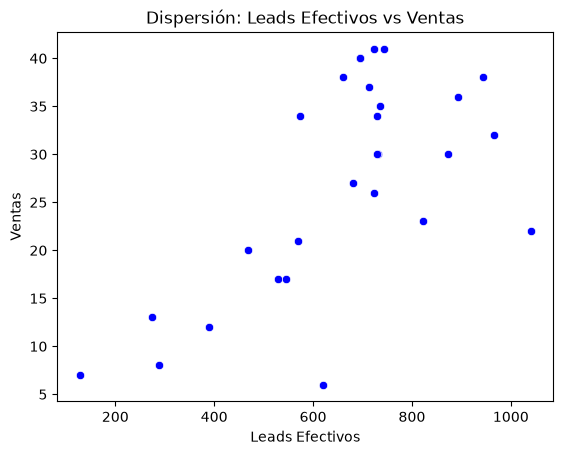

In [10]:
#Imprimimos el scatter plot entre la variable dependiente (Ventas) y la independiente (Efectivos)
#para observar el comportamiento de su dispersión
sns.scatterplot(x='Efectivos', y='Ventas', color='blue', data=df_leads_completo)
plt.title('Dispersión: Leads Efectivos vs Ventas')
plt.xlabel('Leads Efectivos')
plt.ylabel('Ventas')
plt.show()


Regresión Lineal Simple: Efectivos a Ventas

In [11]:
#Declaramos las variables independiente y dependiente para la regresión lineal
Var_Indep_Efectivos = df_leads_completo[['Efectivos']]
Var_Dep_Ventas = df_leads_completo['Ventas']


In [12]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [13]:
#Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model = LinearRegression()


In [14]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Var_Indep_Efectivos, y=Var_Dep_Ventas)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.03]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Efectivos']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.353
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [15]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__


{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Efectivos'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.03425144]),
 'rank_': np.int64(1),
 'singular_': array([1101.17910831]),
 'intercept_': np.float64(4.3534404597081355)}

In [16]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente de Determinación (R2)
model.score(Var_Indep_Efectivos, Var_Dep_Ventas)


0.4288771119533772

In [17]:
#Predecimos los valores de Ventas a partir de la variable "Efectivos"
y_pred = model.predict(X=df_leads_completo[['Efectivos']])
y_pred


array([17.67725168,  8.73762513, 14.21785596, 13.73833576, 25.58933494,
       23.87676281, 23.05472818, 22.5067051 , 32.50812637, 39.97494088,
       37.40608268, 29.11723354, 20.38311565, 29.39124508, 34.22069851,
       24.01376858, 28.1239417 , 34.9399788 , 27.67867295, 26.95939265,
       28.15819315, 29.83651384, 29.3227422 , 28.80897056, 29.35699364,
       36.68680238, 29.15148498, 29.5625023 ])

In [18]:
#Insertamos la columna de predicciones en el DataFrame
df_leads_completo.insert(0, 'Ventas_Predichas', y_pred)
df_leads_completo


,Ventas_Predichas,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion (%),Efectividad de Leads (%)
0,17.677252,2024,2,543.0,108.0,33.0,0.0,1.0,389.0,1.0,12.0,3.1,72.0
1,8.737625,2024,3,178.0,37.0,13.0,0.0,0.0,128.0,1.0,7.0,5.5,72.0
2,14.217856,2024,4,416.0,79.0,46.0,3.0,0.0,288.0,1.0,8.0,2.8,69.0
3,13.738336,2024,5,422.0,33.0,100.0,17.0,0.0,274.0,5.0,13.0,4.7,65.0
4,25.589335,2024,6,967.0,140.0,173.0,31.0,3.0,620.0,17.0,6.0,1.0,64.0
5,23.876763,2024,7,954.0,112.0,251.0,12.0,9.0,570.0,5.0,21.0,3.7,60.0
6,23.054728,2024,8,1409.0,504.0,324.0,17.0,18.0,546.0,22.0,17.0,3.1,39.0
7,22.506705,2024,9,1315.0,431.0,314.0,14.0,26.0,530.0,42.0,17.0,3.2,40.0
8,32.508126,2024,10,1973.0,514.0,606.0,18.0,13.0,822.0,72.0,23.0,2.8,42.0
9,39.974941,2024,11,1562.0,153.0,321.0,44.0,4.0,1040.0,79.0,22.0,2.1,67.0


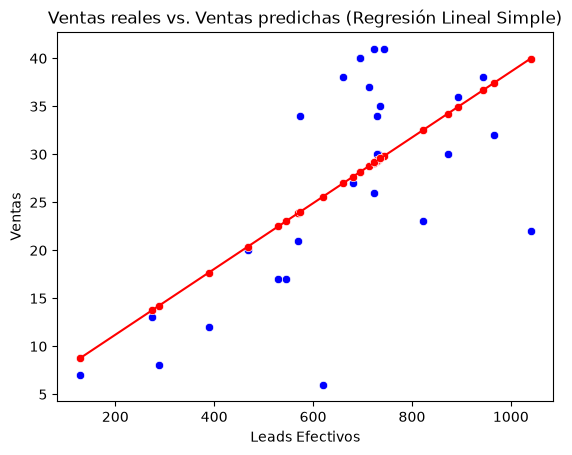

In [19]:
#Visualizamos la gráfica comparativa entre las Ventas reales y las Ventas predichas

sns.scatterplot(x='Efectivos', y='Ventas', color='blue', data=df_leads_completo)
sns.scatterplot(x='Efectivos', y='Ventas_Predichas', color='red', data=df_leads_completo)
sns.lineplot(x='Efectivos', y='Ventas_Predichas', color='red', data=df_leads_completo)
plt.title('Ventas reales vs. Ventas predichas (Regresión Lineal Simple)')
plt.xlabel('Leads Efectivos')
plt.ylabel('Ventas')
plt.show()


In [20]:
#Corroboramos cuál es el coeficiente de Determinación de nuestro modelo
coef_Deter = model.score(X=Var_Indep_Efectivos, y=Var_Dep_Ventas)
coef_Deter


0.4288771119533772

In [21]:
#Corroboramos cuál es el coeficiente de Correlación de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
coef_Correl


np.float64(0.6548870986310367)

Correlación entre todos los tipos de Leads

In [22]:
#Confirmamos que ya no quedan columnas de tipo texto en el DataFrame
df_leads_completo.dtypes


Ventas_Predichas            float64
Año                           int64
Mes                           int64
Total                       float64
Ilocalizable                float64
No Contesta                 float64
D. Incorrectos              float64
Duplicados                  float64
Efectivos                   float64
Abiertos                    float64
Ventas                      float64
Conversion (%)              float64
Efectividad de Leads (%)    float64
dtype: object

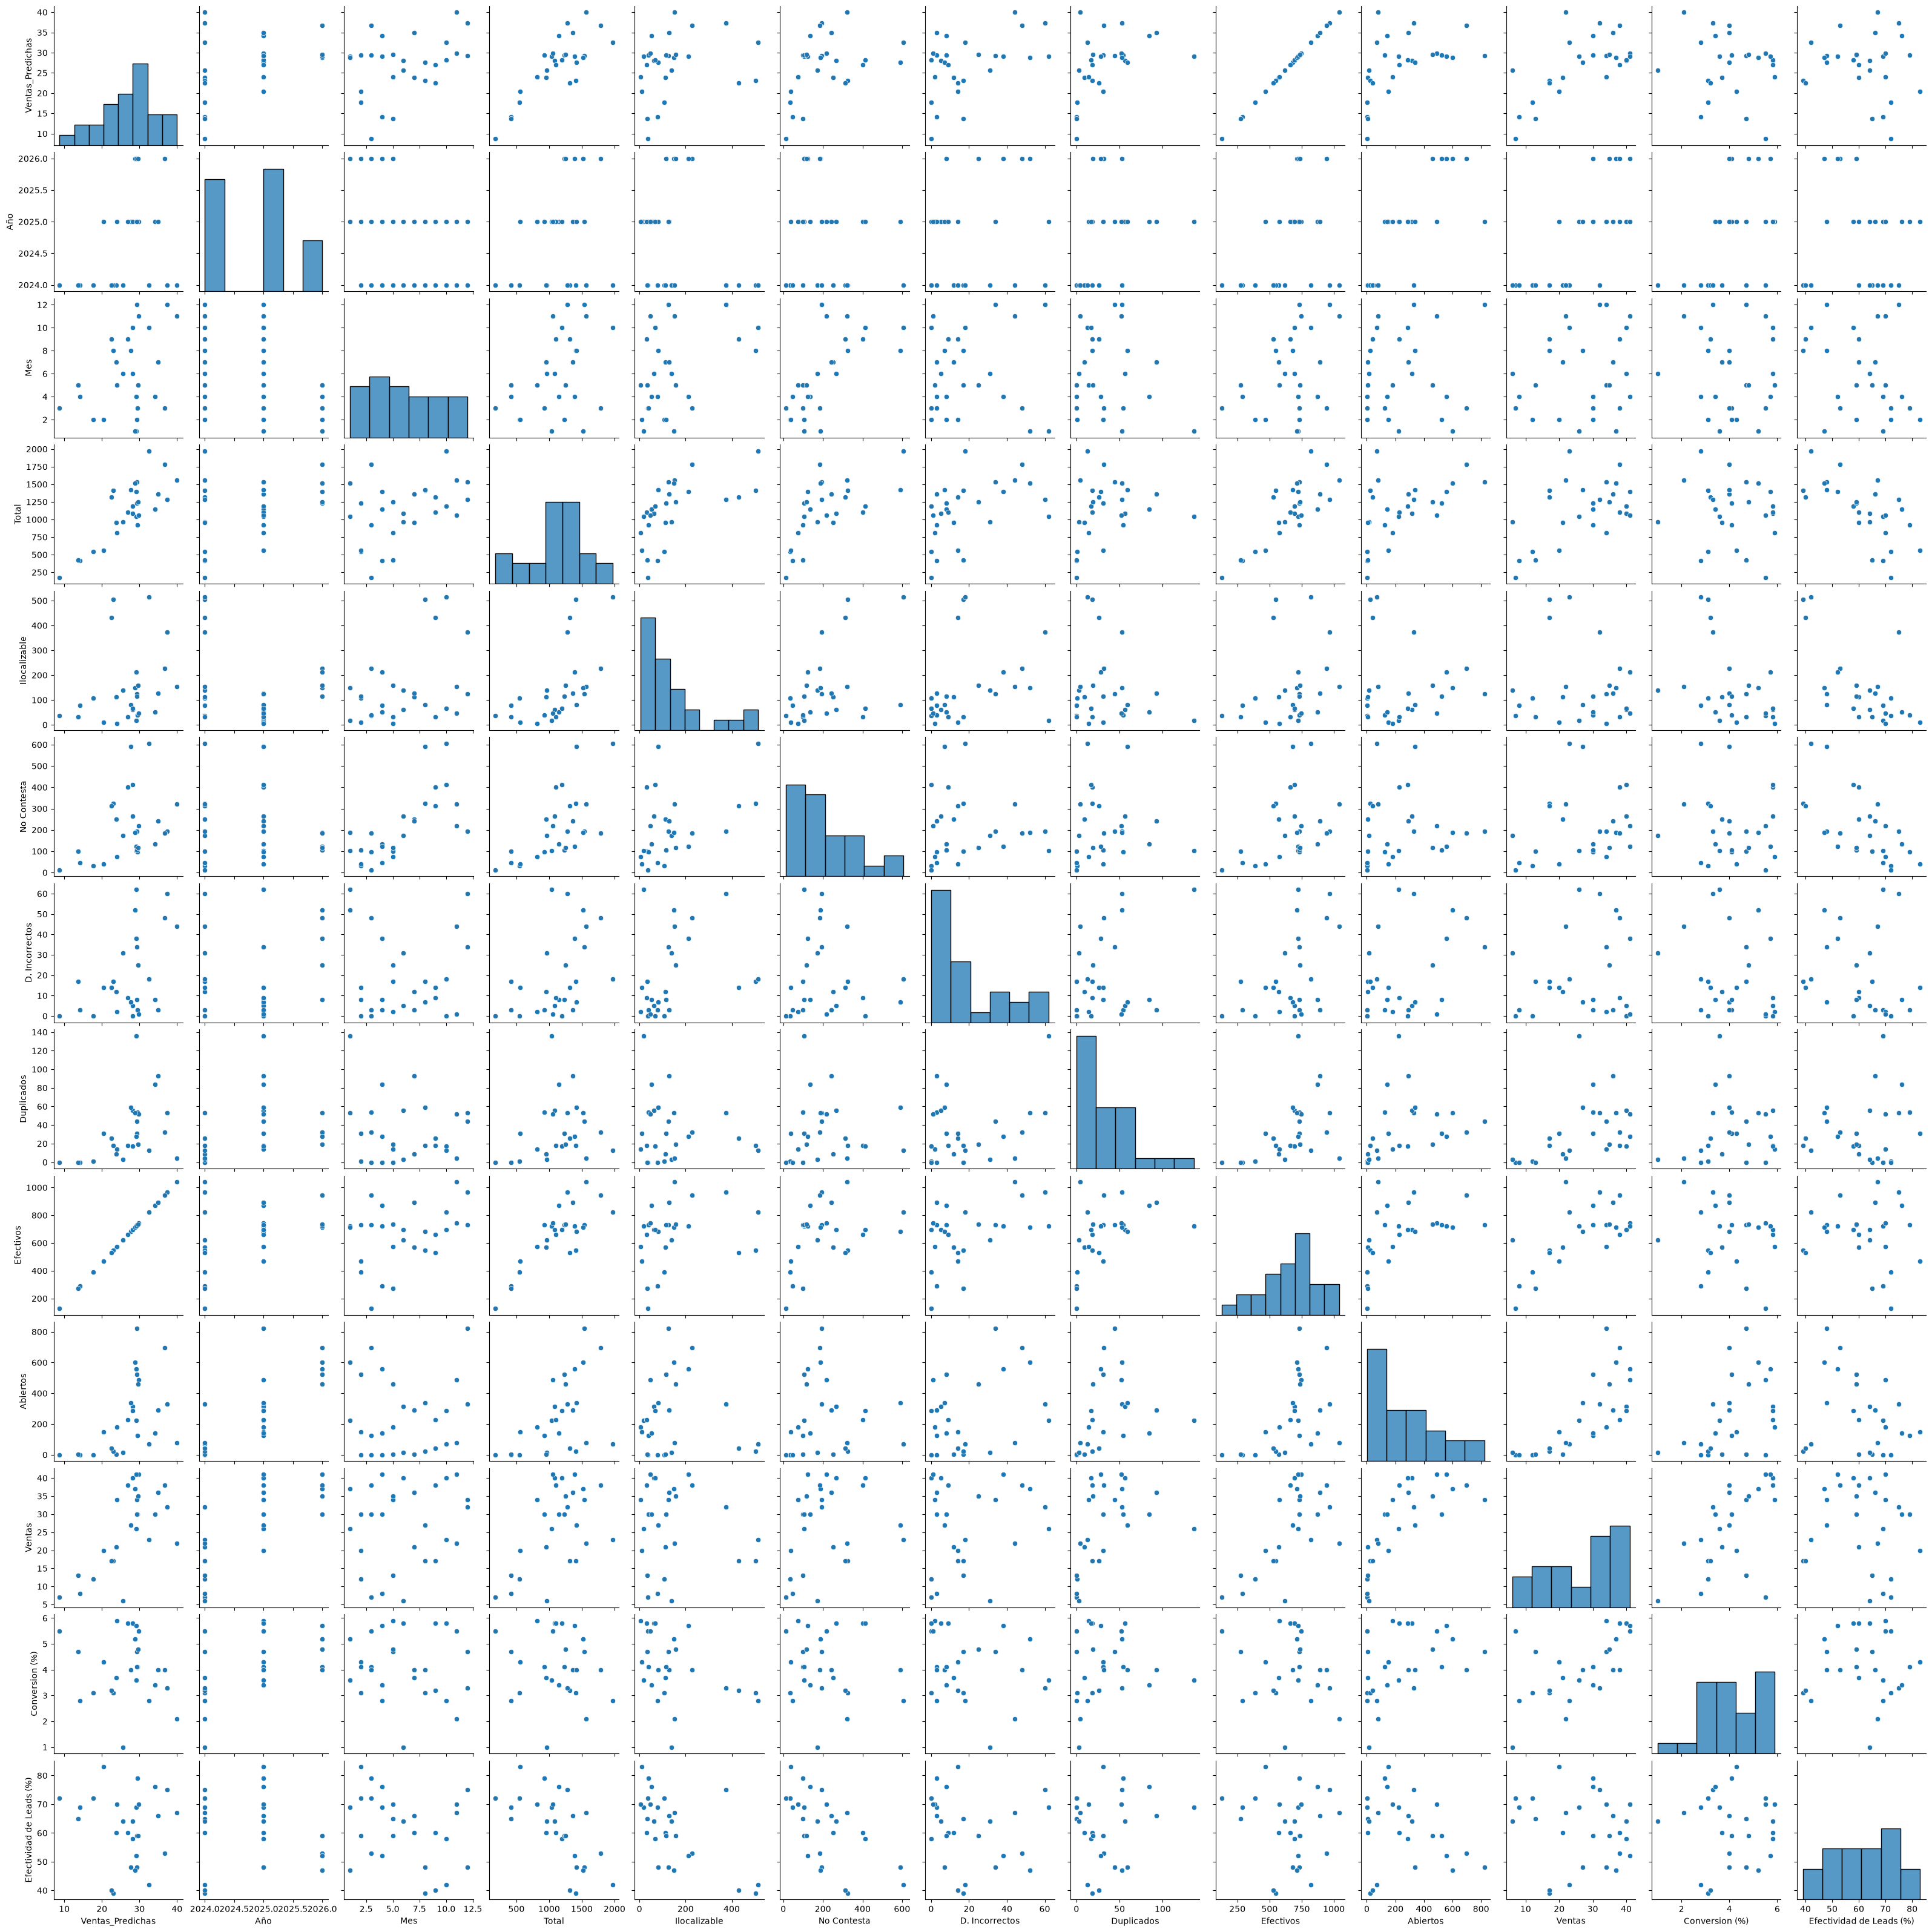

In [23]:
#Graficamos todas las dispersiones entre todas las variables (Total, Ilocalizable, No Contesta,
#D. Incorrectos, Duplicados, Efectivos, Abiertos, Ventas, Conversión, Efectividad de Leads, etc.)
sns.pairplot(df_leads_completo)


In [24]:
#Encontramos todas las correlaciones entre las variables de Leads
Corr_Factors = df_leads_completo.corr()
Corr_Factors


,Ventas_Predichas,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion (%),Efectividad de Leads (%)
Ventas_Predichas,1.000000,0.387510,0.355581,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,-0.137212,-0.115353
Año,0.387510,1.000000,-0.371581,0.344364,-0.266705,-0.131004,0.180612,0.372096,0.387510,0.800323,0.745898,0.536228,-0.105934
Mes,0.355581,-0.371581,1.000000,0.417563,0.393890,0.641403,0.000990,-0.136307,0.355581,0.054022,0.184924,-0.077131,-0.302947
Total,0.812001,0.344364,0.417563,1.000000,0.588110,0.644815,0.453006,0.260949,0.812001,0.528382,0.534564,-0.133595,-0.653776
Ilocalizable,0.245740,-0.266705,0.393890,0.588110,1.000000,0.443577,0.293649,-0.162391,0.245740,-0.047827,-0.106959,-0.413785,-0.645820
No Contesta,0.383725,-0.131004,0.641403,0.644815,0.443577,1.000000,-0.040028,0.012199,0.383725,0.013522,0.219976,-0.088043,-0.611360
D. Incorrectos,0.468292,0.180612,0.000990,0.453006,0.293649,-0.040028,1.000000,0.287165,0.468292,0.382420,0.143903,-0.247300,-0.177488
Duplicados,0.467451,0.372096,-0.136307,0.260949,-0.162391,0.012199,0.287165,1.000000,0.467451,0.336402,0.451099,0.085728,0.139829
Efectivos,1.000000,0.387510,0.355581,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,-0.137212,-0.115353
Abiertos,0.495192,0.800323,0.054022,0.528382,-0.047827,0.013522,0.382420,0.336402,0.495192,1.000000,0.752551,0.445734,-0.281941


In [25]:
#Encontramos el valor absoluto de todas las correlaciones entre las variables de Leads
Corr_Factors1 = abs(Corr_Factors)
Corr_Factors1


,Ventas_Predichas,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion (%),Efectividad de Leads (%)
Ventas_Predichas,1.000000,0.387510,0.355581,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,0.137212,0.115353
Año,0.387510,1.000000,0.371581,0.344364,0.266705,0.131004,0.180612,0.372096,0.387510,0.800323,0.745898,0.536228,0.105934
Mes,0.355581,0.371581,1.000000,0.417563,0.393890,0.641403,0.000990,0.136307,0.355581,0.054022,0.184924,0.077131,0.302947
Total,0.812001,0.344364,0.417563,1.000000,0.588110,0.644815,0.453006,0.260949,0.812001,0.528382,0.534564,0.133595,0.653776
Ilocalizable,0.245740,0.266705,0.393890,0.588110,1.000000,0.443577,0.293649,0.162391,0.245740,0.047827,0.106959,0.413785,0.645820
No Contesta,0.383725,0.131004,0.641403,0.644815,0.443577,1.000000,0.040028,0.012199,0.383725,0.013522,0.219976,0.088043,0.611360
D. Incorrectos,0.468292,0.180612,0.000990,0.453006,0.293649,0.040028,1.000000,0.287165,0.468292,0.382420,0.143903,0.247300,0.177488
Duplicados,0.467451,0.372096,0.136307,0.260949,0.162391,0.012199,0.287165,1.000000,0.467451,0.336402,0.451099,0.085728,0.139829
Efectivos,1.000000,0.387510,0.355581,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,0.137212,0.115353
Abiertos,0.495192,0.800323,0.054022,0.528382,0.047827,0.013522,0.382420,0.336402,0.495192,1.000000,0.752551,0.445734,0.281941


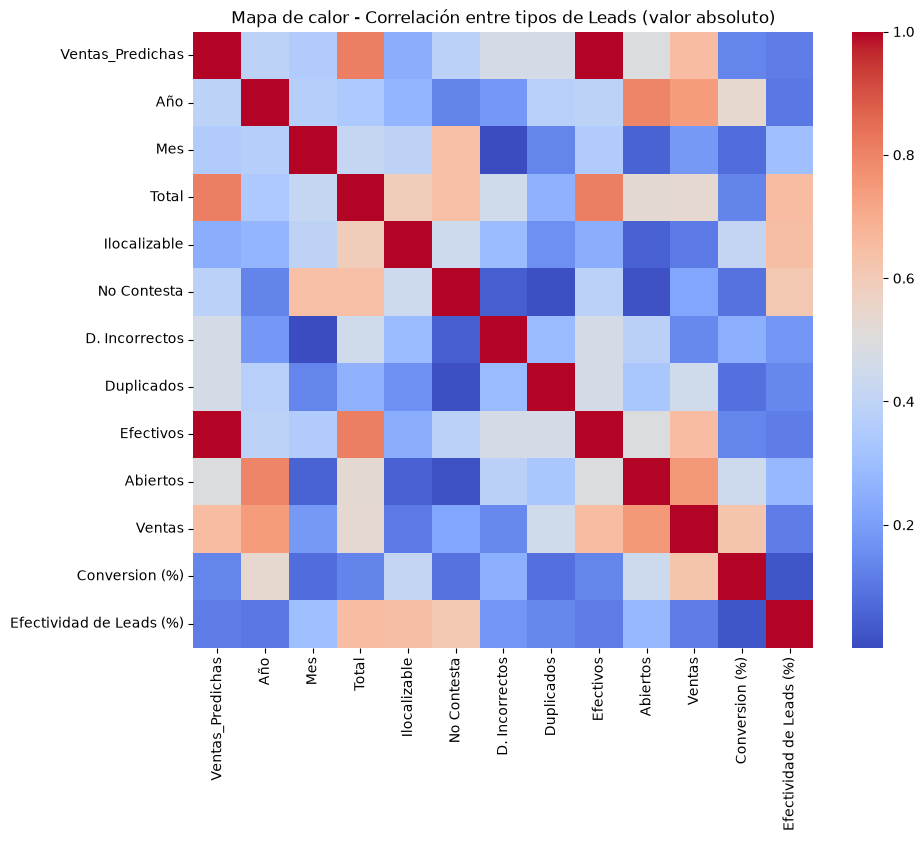

In [26]:
#Graficamos el mapa de calor de los coeficientes de correlación entre los tipos de Leads
plt.figure(figsize=(10, 8))
Heat_Map = sns.heatmap(Corr_Factors1, cmap='coolwarm')
plt.title('Mapa de calor - Correlación entre tipos de Leads (valor absoluto)')
plt.show()


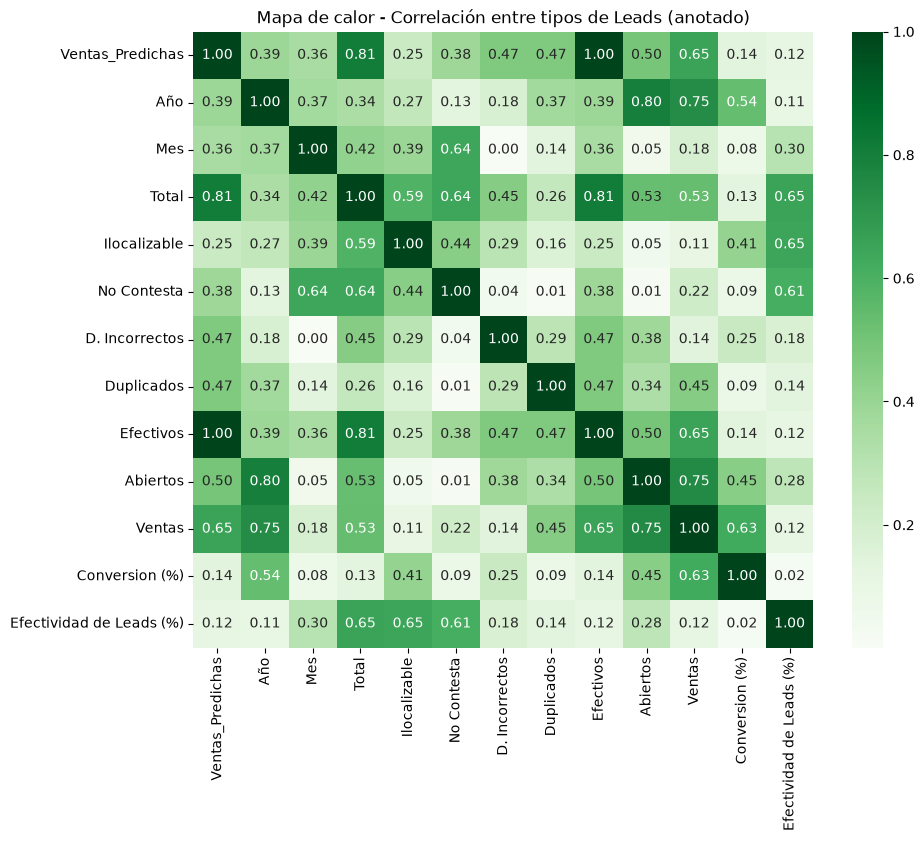

In [27]:
#Ajustamos el mapa de calor de los coeficientes de correlación (con anotaciones)
plt.figure(figsize=(10, 8))
Heat_Map = sns.heatmap(Corr_Factors1, cmap='Greens', annot=True, fmt='.2f')
plt.title('Mapa de calor - Correlación entre tipos de Leads (anotado)')
plt.show()
